In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

# пути к файлам
RAW = Path.cwd().parent / 'data' / 'raw'

# ВАЖНО: в Excel первые 2 строки — метаданные (название отчёта и пустая),
# поэтому skiprows=2, а header — 3-я строка (индекс 2)
income = pd.read_excel(RAW / 'dzen_income.xlsx', skiprows=2)
stat = pd.read_excel(RAW / 'dzen_stat.xlsx', skiprows=2)

print("=== INCOME ===")
print("Размер:", income.shape)
print("Колонки:", income.columns.tolist())
print(income.head(3))

print("\n=== STAT ===")
print("Размер:", stat.shape)
print("Колонки:", stat.columns.tolist())
print(stat.head(3))

=== INCOME ===
Размер: (201, 10)
Колонки: ['Публикация', 'Ссылка на публикацию', 'Дата публикации', 'Тип публикации', 'Суммарный доход', 'За подписчиков', 'За рекламу', 'За время просмотра', 'За стеллы', 'Прочее']
                                         Публикация                               Ссылка на публикацию Дата публикации Тип публикации  Суммарный доход  За подписчиков  За рекламу  \
0                                             Всего                                                NaN             NaN            NaN         50742.56               0           0   
1  В ЦСКА определили тренерский штаб на новый сезон  https://dzen.ru/media/id/6358cb994fee997bedba5...      30.05.2026         Статья          1870.59               0           0   
2                  Алексей Батраков переходит в ПСЖ  https://dzen.ru/media/id/6358cb994fee997bedba5...      01.06.2026         Статья          1502.94               0           0   

   За время просмотра  За стеллы  Прочее  
0            5

d:\Projects\dzen-analysis\venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [2]:
# --- INCOME ---
income_clean = income.copy()
income_clean = income_clean[income_clean['Публикация'] != 'Всего'].reset_index(drop=True)

# --- STAT ---
stat_clean = stat.copy()
stat_clean = stat_clean[stat_clean['Дата публикации'] != 'Всего'].reset_index(drop=True)

print("INCOME после чистки:", income_clean.shape)
print("STAT после чистки:", stat_clean.shape)

# парсим даты
income_clean['Дата публикации'] = pd.to_datetime(
    income_clean['Дата публикации'], format='%d.%m.%Y', errors='coerce'
)
stat_clean['Дата публикации'] = pd.to_datetime(
    stat_clean['Дата публикации'], errors='coerce'
)

print("\nДаты income:", income_clean['Дата публикации'].min(), '→', income_clean['Дата публикации'].max())
print("Даты stat:  ", stat_clean['Дата публикации'].min(), '→', stat_clean['Дата публикации'].max())

print("\nТипы публикаций в INCOME:")
print(income_clean['Тип публикации'].value_counts())

print("\nТипы публикаций в STAT:")
print(stat_clean['Тип публикации'].value_counts())

INCOME после чистки: (200, 10)
STAT после чистки: (614, 12)

Даты income: 2024-04-16 00:00:00 → 2026-09-15 00:00:00
Даты stat:   2022-10-26 08:56:13.449000 → 2026-09-17 09:44:23.754000

Типы публикаций в INCOME:
Тип публикации
Статья    199
Пост        1
Name: count, dtype: int64

Типы публикаций в STAT:
Тип публикации
Видео     322
Статья    250
Ролик      37
Пост        5
Name: count, dtype: int64


In [3]:
# уникальность ссылок
print("Уникальных ссылок в INCOME:", income_clean['Ссылка на публикацию'].nunique())
print("Уникальных ссылок в STAT:  ", stat_clean['Ссылка на публикацию'].nunique())

# сколько ссылок есть в обоих
common = set(income_clean['Ссылка на публикацию']) & set(stat_clean['Ссылка на публикацию'])
print("\nОбщих ссылок:", len(common))
print("Только в INCOME:", len(set(income_clean['Ссылка на публикацию']) - common))
print("Только в STAT:  ", len(set(stat_clean['Ссылка на публикацию']) - common))

Уникальных ссылок в INCOME: 200
Уникальных ссылок в STAT:   614

Общих ссылок: 200
Только в INCOME: 0
Только в STAT:   414


In [4]:
# объединяем по ссылке
df = pd.merge(
    stat_clean,
    income_clean[['Ссылка на публикацию', 'Суммарный доход', 'За время просмотра']],
    on='Ссылка на публикацию',
    how='left'
)

print("Объединённый df:", df.shape)
print("\nПубликаций с доходом:", df['Суммарный доход'].notna().sum())
print("Публикаций без дохода:", df['Суммарный доход'].isna().sum())
print("\nОбщий доход:", df['Суммарный доход'].sum().round(2), "₽")

Объединённый df: (614, 14)

Публикаций с доходом: 200
Публикаций без дохода: 414

Общий доход: 50702.87 ₽


In [5]:
# CTR = Открытия / Показы (насколько кликают)
df['CTR'] = df['Открытия'] / df['Показы']

# Completion Rate = Дочитывания / Открытия (насколько дочитывают)
df['CR'] = df['Дочитывания и просмотры'] / df['Открытия']

# Engagement rate = (Лайки + Комментарии) / Дочитывания
df['ER'] = (df['Лайки'] + df['Комментарии']) / df['Дочитывания и просмотры']

# доход на 1000 просмотров (RPM)
df['RPM'] = df['Суммарный доход'] / df['Дочитывания и просмотры'] * 1000

# месяц публикации (для сезонности)
df['year_month'] = df['Дата публикации'].dt.to_period('M').astype(str)
df['weekday'] = df['Дата публикации'].dt.day_name()
df['hour'] = df['Дата публикации'].dt.hour
df['month'] = df['Дата публикации'].dt.month

print(df[['CTR', 'CR', 'ER', 'RPM']].describe().round(4))

            CTR        CR        ER       RPM
count  614.0000  565.0000  527.0000  200.0000
mean     0.0632       inf    0.0138   38.8744
std      0.0993       NaN    0.0568   15.4504
min      0.0000    0.0000    0.0000    0.9910
25%      0.0162    0.5802    0.0000   28.7022
50%      0.0395    0.8362    0.0000   34.9382
75%      0.0718    1.9775    0.0089   48.1763
max      1.4286       inf    1.0000  100.0000


d:\Projects\dzen-analysis\venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [6]:
# объединяем по ссылке
df = pd.merge(
    stat_clean,
    income_clean[['Ссылка на публикацию', 'Суммарный доход', 'За время просмотра', 'Прочее']],
    on='Ссылка на публикацию',
    how='left'
)

print("Объединённый df:", df.shape)
print("\nПубликаций с доходом:", df['Суммарный доход'].notna().sum())
print("Публикаций без дохода:", df['Суммарный доход'].isna().sum())
print("Общий доход:", df['Суммарный доход'].sum().round(2), "₽")

# типы публикаций в объединённом датасете
print("\nТипы публикаций:")
print(df['Тип публикации'].value_counts())

Объединённый df: (614, 15)

Публикаций с доходом: 200
Публикаций без дохода: 414
Общий доход: 50702.87 ₽

Типы публикаций:
Тип публикации
Видео     322
Статья    250
Ролик      37
Пост        5
Name: count, dtype: int64


In [7]:
# CTR = Открытия / Показы (кликабельность)
df['CTR'] = df['Открытия'] / df['Показы']

# Completion Rate = Дочитывания / Открытия
df['CR'] = df['Дочитывания и просмотры'] / df['Открытия']

# Engagement Rate = (Лайки + Комментарии) / Дочитывания
df['ER'] = (df['Лайки'] + df['Комментарии']) / df['Дочитывания и просмотры']

# RPM — доход на 1000 просмотров
df['RPM'] = df['Суммарный доход'] / df['Дочитывания и просмотры'] * 1000

# временные фичи
df['year_month'] = df['Дата публикации'].dt.to_period('M').astype(str)
df['weekday'] = df['Дата публикации'].dt.day_name()
df['hour'] = df['Дата публикации'].dt.hour
df['month'] = df['Дата публикации'].dt.month

print("=== Описательная статистика метрик ===")
print(df[['CTR', 'CR', 'ER', 'RPM']].describe().round(4))

=== Описательная статистика метрик ===
            CTR        CR        ER       RPM
count  614.0000  565.0000  527.0000  200.0000
mean     0.0632       inf    0.0138   38.8744
std      0.0993       NaN    0.0568   15.4504
min      0.0000    0.0000    0.0000    0.9910
25%      0.0162    0.5802    0.0000   28.7022
50%      0.0395    0.8362    0.0000   34.9382
75%      0.0718    1.9775    0.0089   48.1763
max      1.4286       inf    1.0000  100.0000


d:\Projects\dzen-analysis\venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [8]:
# сравнение метрик видео vs статей (за весь период)
print("=== Средние метрики по типам ===")
print(df.groupby('Тип публикации')[['Показы', 'Открытия', 'CTR', 'CR', 'ER']].mean().round(4))

=== Средние метрики по типам ===
                     Показы   Открытия     CTR      CR      ER
Тип публикации                                                
Видео            12278.6335   251.3665  0.0482     inf  0.0047
Пост                14.2000     4.2000  0.3000  0.3750  0.0000
Ролик              464.9730    72.1081  0.0853  3.1977  0.0262
Статья          134268.2840  9224.9360  0.0746     inf  0.0239


In [9]:
# рабочий датасет для анализа дохода
df_income = df[df['Суммарный доход'].notna()].copy()
print("\nРабочий датасет (статьи с доходом):", df_income.shape)


Рабочий датасет (статьи с доходом): (200, 23)


In [10]:
# 1. Сколько публикаций с CTR > 1
print("CTR > 1:", (df['CTR'] > 1).sum())
print(df[df['CTR'] > 1][['Публикация', 'Тип публикации', 'Показы', 'Открытия', 'CTR']].head(10))

# 2. Сколько публикаций с CR > 1
print("\nCR > 1:", (df['CR'] > 1).sum())
print(df[df['CR'] > 1][['Публикация', 'Тип публикации', 'Открытия', 'Дочитывания и просмотры', 'CR']].head(10))

# 3. Публикации с 0 открытий
print("\nОткрытия == 0:", (df['Открытия'] == 0).sum())
print(df[df['Открытия'] == 0][['Публикация', 'Тип публикации', 'Показы', 'Открытия', 'Дочитывания и просмотры']].head(10))

CTR > 1: 1
                                            Публикация Тип публикации  Показы  Открытия       CTR
379  🏆Когда пройдут финалы топовых национальных и е...           Пост      14        20  1.428571

CR > 1: 221
                                            Публикация Тип публикации  Открытия  Дочитывания и просмотры        CR
171  Трансферы РПЛ • Лето 2025 #7 • В Спартаке новы...          Видео      1592                     3422  2.149497
203                   Посредственный трансфер Спартака         Статья         0                        1       inf
226            Лига Европы УЕФА (2001-2025) Победители          Ролик       301                      619  2.056478
235  Чемпионат Мира по футболу (1930 - 2022) Все по...          Видео       632                     1740  2.753165
236  Победители Кубка Англии в 21 веке (2001-2025) ...          Ролик       300                      395  1.316667
245  НЕПОБЕЖДЕННЫЕ соперники РЕАЛ МАДРИДа в Еврокуб...          Ролик       363           

In [11]:
# создаём "чистые" метрики — там, где есть данные
df['CTR_clean'] = np.where(df['Показы'] > 0, df['Открытия'] / df['Показы'], np.nan)
df['CR_clean'] = np.where(df['Открытия'] > 0, df['Дочитывания и просмотры'] / df['Открытия'], np.nan)
df['ER_clean'] = np.where(
    df['Дочитывания и просмотры'] > 0,
    (df['Лайки'] + df['Комментарии']) / df['Дочитывания и просмотры'],
    np.nan
)

# обрезаем физически невозможные значения
df.loc[df['CTR_clean'] > 1, 'CTR_clean'] = np.nan
df.loc[df['CR_clean'] > 1, 'CR_clean'] = np.nan
df.loc[df['ER_clean'] > 1, 'ER_clean'] = np.nan

# описательная статистика по чистым метрикам
print("=== Чистые метрики ===")
print(df[['CTR_clean', 'CR_clean', 'ER_clean', 'RPM']].describe().round(4))

=== Чистые метрики ===
       CTR_clean  CR_clean  ER_clean       RPM
count   613.0000  344.0000  527.0000  200.0000
mean      0.0610    0.5847    0.0138   38.8744
std       0.0826    0.2952    0.0568   15.4504
min       0.0000    0.0000    0.0000    0.9910
25%       0.0161    0.3990    0.0000   28.7022
50%       0.0394    0.6463    0.0000   34.9382
75%       0.0716    0.7842    0.0089   48.1763
max       0.8636    1.0000    1.0000  100.0000


In [12]:
# рабочий датасет: только статьи с доходом за период
df_work = df[
    (df['Суммарный доход'].notna()) &
    (df['Тип публикации'] == 'Статья')
].copy()

print("Рабочий датасет:", df_work.shape)
print("\nДоход:", df_work['Суммарный доход'].sum().round(2), "₽")
print("Период:", df_work['Дата публикации'].min(), '→', df_work['Дата публикации'].max())

print("\n=== Метрики рабочего датасета ===")
print(df_work[['CTR_clean', 'CR_clean', 'ER_clean', 'RPM', 'Суммарный доход']].describe().round(4))

Рабочий датасет: (199, 26)

Доход: 50702.49 ₽
Период: 2024-11-12 18:41:32.466000 → 2026-09-15 10:12:00.401000

=== Метрики рабочего датасета ===
       CTR_clean  CR_clean  ER_clean       RPM  Суммарный доход
count   199.0000  198.0000  199.0000  199.0000         199.0000
mean      0.0770    0.6023    0.0254   38.9425         254.7864
std       0.0650    0.1712    0.0781   15.4593         324.0040
min       0.0000    0.1222    0.0000    0.9910           0.0300
25%       0.0365    0.4857    0.0056   28.8978          26.8700
50%       0.0608    0.6387    0.0097   34.9510         124.0600
75%       0.0952    0.7319    0.0193   48.3526         390.4850
max       0.5298    1.0000    1.0000  100.0000        1870.5900


In [13]:
# проверим на дубликаты ссылок
dups_income = income_clean[income_clean.duplicated('Ссылка на публикацию', keep=False)]
print("Дубликаты ссылок в INCOME:", len(dups_income))

dups_stat = stat_clean[stat_clean.duplicated('Ссылка на публикацию', keep=False)]
print("Дубликаты ссылок в STAT:", len(dups_stat))

# разница в доходе
print("\nДоход в income_clean:", income_clean['Суммарный доход'].sum().round(2))
print("Доход в объединённом df:", df['Суммарный доход'].sum().round(2))
print("Разница:", round(income_clean['Суммарный доход'].sum() - df['Суммарный доход'].sum(), 2))

Дубликаты ссылок в INCOME: 0
Дубликаты ссылок в STAT: 0

Доход в income_clean: 50702.87
Доход в объединённом df: 50702.87
Разница: -0.0


In [14]:
# рабочий датасет — только статьи с доходом
df_work = df[
    (df['Суммарный доход'].notna()) &
    (df['Тип публикации'] == 'Статья')
].copy()

# убираем статьи с 0 открытий (они не информативны для анализа CTR/CR)
df_work = df_work[df_work['Открытия'] > 0].reset_index(drop=True)

print("Рабочий датасет:", df_work.shape)
print("Доход:", df_work['Суммарный доход'].sum().round(2), "₽")
print("Период:", df_work['Дата публикации'].min(), '→', df_work['Дата публикации'].max())

# сохраняем
PROCESSED = Path.cwd().parent / 'data' / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)

df.to_csv(PROCESSED / 'dzen_all.csv', index=False)
df_work.to_csv(PROCESSED / 'dzen_articles.csv', index=False)

print("\nСохранено:")
print(" -", PROCESSED / 'dzen_all.csv', '(все публикации)')
print(" -", PROCESSED / 'dzen_articles.csv', '(только статьи с доходом)')

Рабочий датасет: (198, 26)
Доход: 50702.42 ₽
Период: 2024-11-12 18:41:32.466000 → 2026-09-15 10:12:00.401000

Сохранено:
 - d:\Projects\dzen-analysis\data\processed\dzen_all.csv (все публикации)
 - d:\Projects\dzen-analysis\data\processed\dzen_articles.csv (только статьи с доходом)


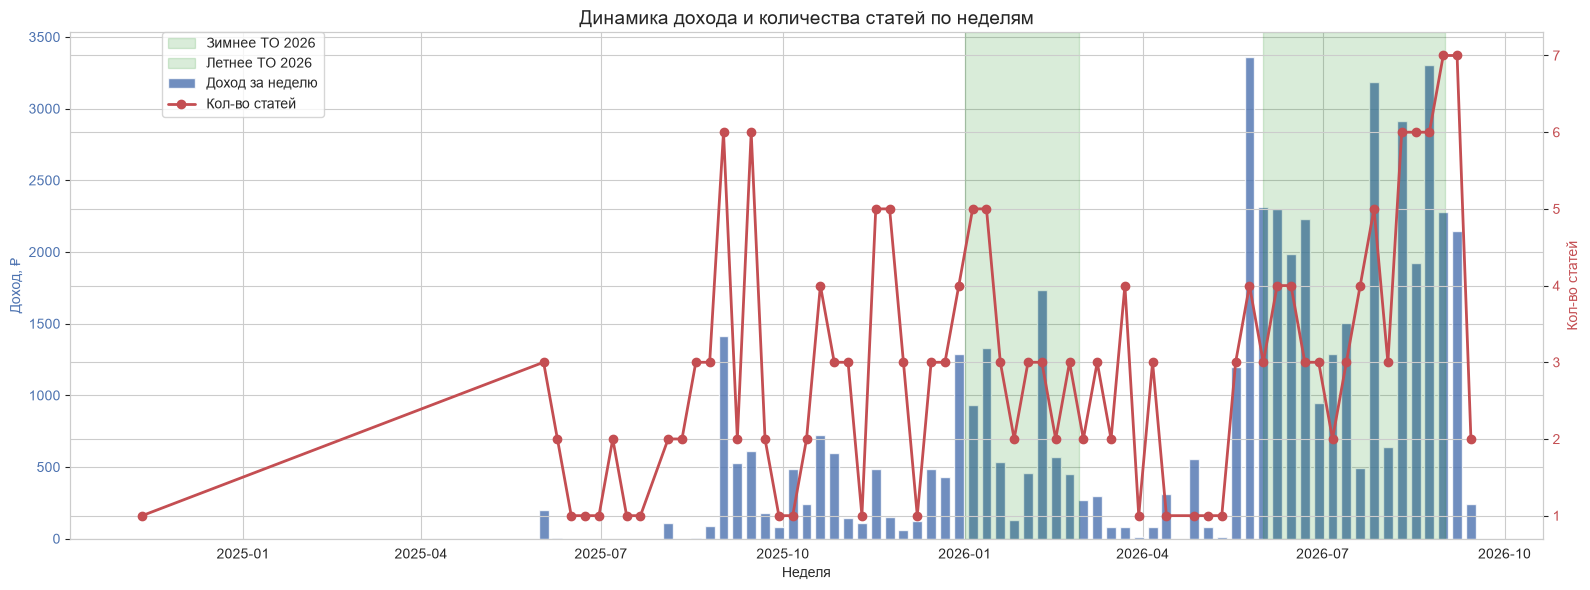

In [15]:
# агрегируем доход по неделям
df_work['week'] = df_work['Дата публикации'].dt.to_period('W').dt.start_time

weekly = df_work.groupby('week').agg(
    income=('Суммарный доход', 'sum'),
    n_articles=('Публикация', 'count'),
    avg_income=('Суммарный доход', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 6))

# столбики — доход по неделям
ax1.bar(weekly['week'], weekly['income'], width=5, color='#4C72B0', alpha=0.8, label='Доход за неделю')
ax1.set_xlabel('Неделя')
ax1.set_ylabel('Доход, ₽', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')

# линия — количество статей
ax2 = ax1.twinx()
ax2.plot(weekly['week'], weekly['n_articles'], color='#C44E52', marker='o', 
         linewidth=2, label='Кол-во статей')
ax2.set_ylabel('Кол-во статей', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')

# выделяем трансферные окна
for start, end, label in [
    ('2026-01-01', '2026-02-28', 'Зимнее ТО 2026'),
    ('2026-06-01', '2026-09-01', 'Летнее ТО 2026'),
]:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color='green', label=label)

plt.title('Динамика дохода и количества статей по неделям', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.savefig(Path.cwd().parent / 'images' / 'income_weekly.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# сортируем статьи по доходу от большего к меньшему
df_work_sorted = df_work.sort_values('Суммарный доход', ascending=False).reset_index(drop=True)

# накопительный доход
df_work_sorted['cum_income'] = df_work_sorted['Суммарный доход'].cumsum()
df_work_sorted['cum_share'] = df_work_sorted['cum_income'] / df_work_sorted['Суммарный доход'].sum()
df_work_sorted['rank_share'] = (df_work_sorted.index + 1) / len(df_work_sorted)

# какой процент статей даёт 50%, 80%, 90% дохода
for pct in [0.5, 0.8, 0.9]:
    n = (df_work_sorted['cum_share'] <= pct).sum() + 1
    share = n / len(df_work_sorted)
    print(f"{pct*100:.0f}% дохода дают {n} статей ({share*100:.1f}% от общего числа)")

# топ-10 статей
top10 = df_work_sorted.head(10)[['Публикация', 'Дата публикации', 'Суммарный доход', 'CTR_clean', 'CR_clean']]
print("\n=== Топ-10 статей по доходу ===")
print(top10.to_string(index=False))

50% дохода дают 29 статей (14.6% от общего числа)
80% дохода дают 66 статей (33.3% от общего числа)
90% дохода дают 91 статей (46.0% от общего числа)

=== Топ-10 статей по доходу ===
                                                                           Публикация         Дата публикации  Суммарный доход  CTR_clean  CR_clean
                                     В ЦСКА определили тренерский штаб на новый сезон 2026-05-30 16:25:15.842          1870.59   0.075910  0.613403
                                                     Алексей Батраков переходит в ПСЖ 2026-06-01 11:34:48.781          1502.94   0.071107  0.610686
                     ЦСКА нашел нападающего, а Зенит заменит опорника / Трансферы РПЛ 2026-07-31 12:16:27.824          1380.37   0.131136  0.830611
                                       Главные кандидаты на усиление в атаку Спартака 2026-08-13 13:45:38.241          1223.15   0.119194  0.677194
 Защитник покидает Краснодар \ ЦСКА покупает Аззи из Динамо Махачкала - Транс

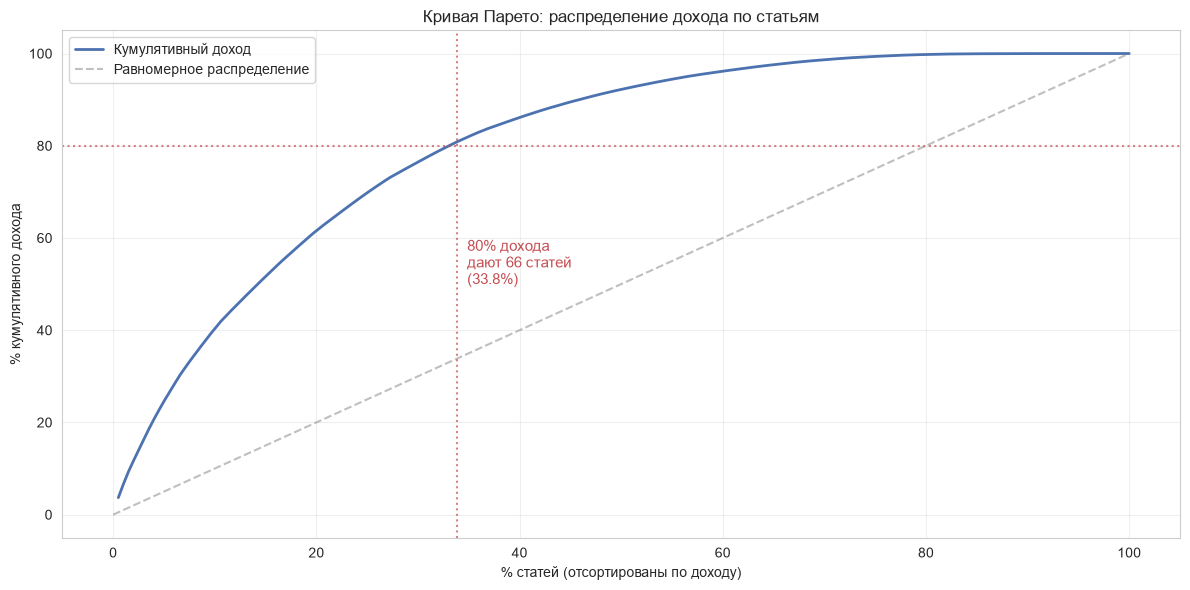

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

# кривая Лоренца
ax.plot(df_work_sorted['rank_share'] * 100, 
        df_work_sorted['cum_share'] * 100, 
        linewidth=2, color='#4C72B0', label='Кумулятивный доход')
ax.plot([0, 100], [0, 100], '--', color='gray', alpha=0.5, label='Равномерное распределение')

# отметка 80%
idx_80 = (df_work_sorted['cum_share'] <= 0.8).sum() + 1
x_80 = df_work_sorted.loc[idx_80, 'rank_share'] * 100
ax.axvline(x_80, color='#C44E52', linestyle=':', alpha=0.7)
ax.axhline(80, color='#C44E52', linestyle=':', alpha=0.7)
ax.text(x_80 + 1, 50, f'80% дохода\nдают {idx_80} статей\n({x_80:.1f}%)', 
        color='#C44E52', fontsize=11)

ax.set_xlabel('% статей (отсортированы по доходу)')
ax.set_ylabel('% кумулятивного дохода')
ax.set_title('Кривая Парето: распределение дохода по статьям')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'images' / 'pareto_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
import re

def categorize(title):
    title_lower = str(title).lower()
    
    # трансферы
    if 'трансферы' in title_lower or 'трансфер' in title_lower:
        return 'Трансферы'
    # история СССР
    if any(w in title_lower for w in ['ссср', 'чемпионат ссср', 'кубок ссср', 'первенство советского']):
        return 'История СССР'
    # матчи / туры / обзоры
    if any(w in title_lower for w in ['тур рпл', 'итоги', 'обзор', 'туров', 'матч', 'перед матчем']):
        return 'Обзоры матчей'
    # сборная России
    if any(w in title_lower for w in ['сборная', 'сборной', 'сборную']):
        return 'Сборная России'
    # слухи и мнения
    if any(w in title_lower for w in ['слухи', 'может', 'интересен', 'хочет']):
        return 'Слухи и мнения'
    # статистика / таблицы
    if any(w in title_lower for w in ['все победители', 'таблица', 'статистика', 'лучшие']):
        return 'Статистика'
    # аналитика
    if any(w in title_lower for w in ['почему', 'разбор', 'анализ', 'главные', 'выводы']):
        return 'Аналитика'
    return 'Другое'

df_work['category'] = df_work['Публикация'].apply(categorize)

# агрегируем по категориям
cat_stats = df_work.groupby('category').agg(
    n=('Публикация', 'count'),
    total_income=('Суммарный доход', 'sum'),
    avg_income=('Суммарный доход', 'mean'),
    median_income=('Суммарный доход', 'median'),
    avg_ctr=('CTR_clean', 'mean'),
    avg_cr=('CR_clean', 'mean'),
).round(2).sort_values('total_income', ascending=False)

print(cat_stats)

                 n  total_income  avg_income  median_income  avg_ctr  avg_cr
category                                                                    
Трансферы       81      27680.29      341.73         246.49     0.10    0.70
Другое          65      13591.41      209.10          43.81     0.06    0.58
История СССР    36       5204.09      144.56         106.34     0.06    0.45
Слухи и мнения   4       1834.94      458.74         452.10     0.07    0.66
Аналитика        1       1223.15     1223.15        1223.15     0.12    0.68
Обзоры матчей    5       1040.46      208.09          82.09     0.04    0.53
Сборная России   5         98.56       19.71          11.97     0.08    0.45
Статистика       1         29.52       29.52          29.52     0.02    0.50


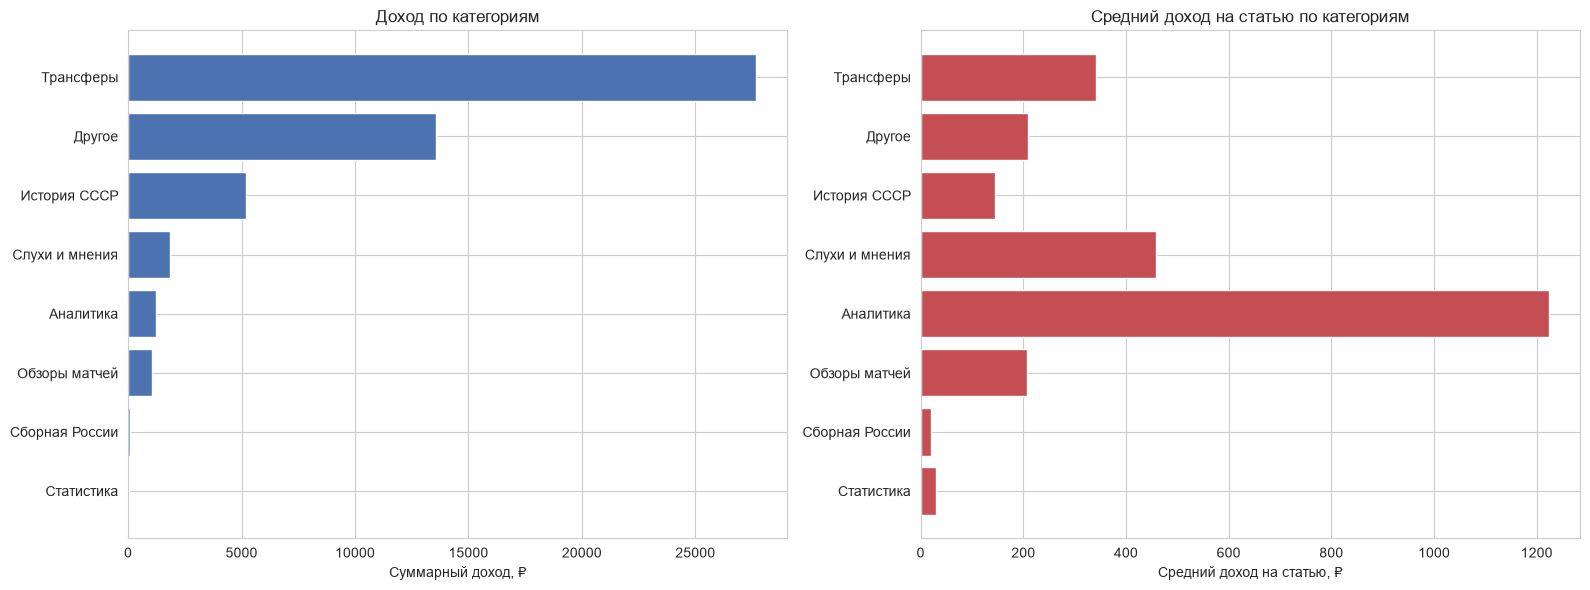

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# доход по категориям
cat_stats_sorted = cat_stats.sort_values('total_income', ascending=True)
axes[0].barh(cat_stats_sorted.index, cat_stats_sorted['total_income'], color='#4C72B0')
axes[0].set_xlabel('Суммарный доход, ₽')
axes[0].set_title('Доход по категориям')

# средний доход по категориям
axes[1].barh(cat_stats_sorted.index, cat_stats_sorted['avg_income'], color='#C44E52')
axes[1].set_xlabel('Средний доход на статью, ₽')
axes[1].set_title('Средний доход на статью по категориям')

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'images' / 'categories_income.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
clubs = ['ЦСКА', 'Спартак', 'Зенит', 'Краснодар', 'Локомотив', 
         'Динамо', 'Ростов', 'Рубин', 'Ахмат', 'Балтика', 'Акрон', 'Факел']

def find_clubs(title):
    title = str(title)
    return [c for c in clubs if c.lower() in title.lower()]

df_work['clubs'] = df_work['Публикация'].apply(find_clubs)

# разворачиваем список клубов в отдельные строки
df_clubs = df_work.explode('clubs')
df_clubs = df_clubs[df_clubs['clubs'].notna()]

club_stats = df_clubs.groupby('clubs').agg(
    n=('Публикация', 'count'),
    total_income=('Суммарный доход', 'sum'),
    avg_income=('Суммарный доход', 'mean'),
    median_income=('Суммарный доход', 'median'),
).round(2).sort_values('total_income', ascending=False)

print(club_stats)

            n  total_income  avg_income  median_income
clubs                                                 
Спартак    46      12871.71      279.82         127.16
ЦСКА       28      12781.79      456.49         360.36
Зенит      27       7009.34      259.61         162.24
Краснодар  19       5901.47      310.60         227.53
Динамо     22       5641.00      256.41         195.98
Локомотив  18       3841.34      213.41         106.34
Балтика     6       3075.98      512.66         405.73
Акрон       6       2979.11      496.52         522.60
Факел       6       2524.60      420.77         313.91
Рубин      10       2217.12      221.71         144.60
Ахмат       8       2091.31      261.41         197.63
Ростов      5       1319.64      263.93         282.95


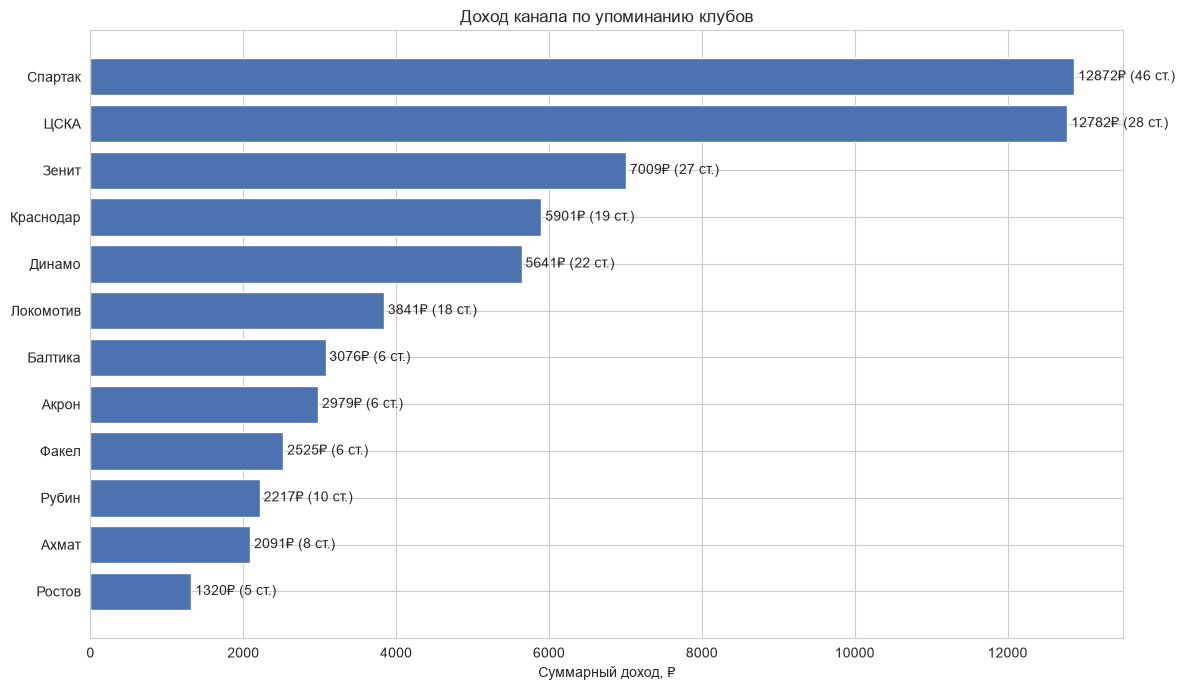

In [21]:
fig, ax = plt.subplots(figsize=(12, 7))

club_stats_top = club_stats.sort_values('total_income', ascending=True)
bars = ax.barh(club_stats_top.index, club_stats_top['total_income'], color='#4C72B0')
ax.set_xlabel('Суммарный доход, ₽')
ax.set_title('Доход канала по упоминанию клубов')

# подписи: суммарный доход + кол-во статей
for bar, (idx, row) in zip(bars, club_stats_top.iterrows()):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{row["total_income"]:.0f}₽ ({int(row["n"])} ст.)',
            va='center', fontsize=10)

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'images' / 'clubs_income.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
top_clubs = ['ЦСКА', 'Спартак', 'Зенит']
df_work['has_top_club'] = df_work['Публикация'].apply(
    lambda t: any(c.lower() in str(t).lower() for c in top_clubs)
)

# статистика: есть топ-клуб vs нет
print(df_work.groupby('has_top_club').agg(
    n=('Публикация', 'count'),
    total_income=('Суммарный доход', 'sum'),
    avg_income=('Суммарный доход', 'mean'),
    median_income=('Суммарный доход', 'median'),
).round(2))

                n  total_income  avg_income  median_income
has_top_club                                              
False         110      22733.48      206.67         113.93
True           88      27968.94      317.83         153.98


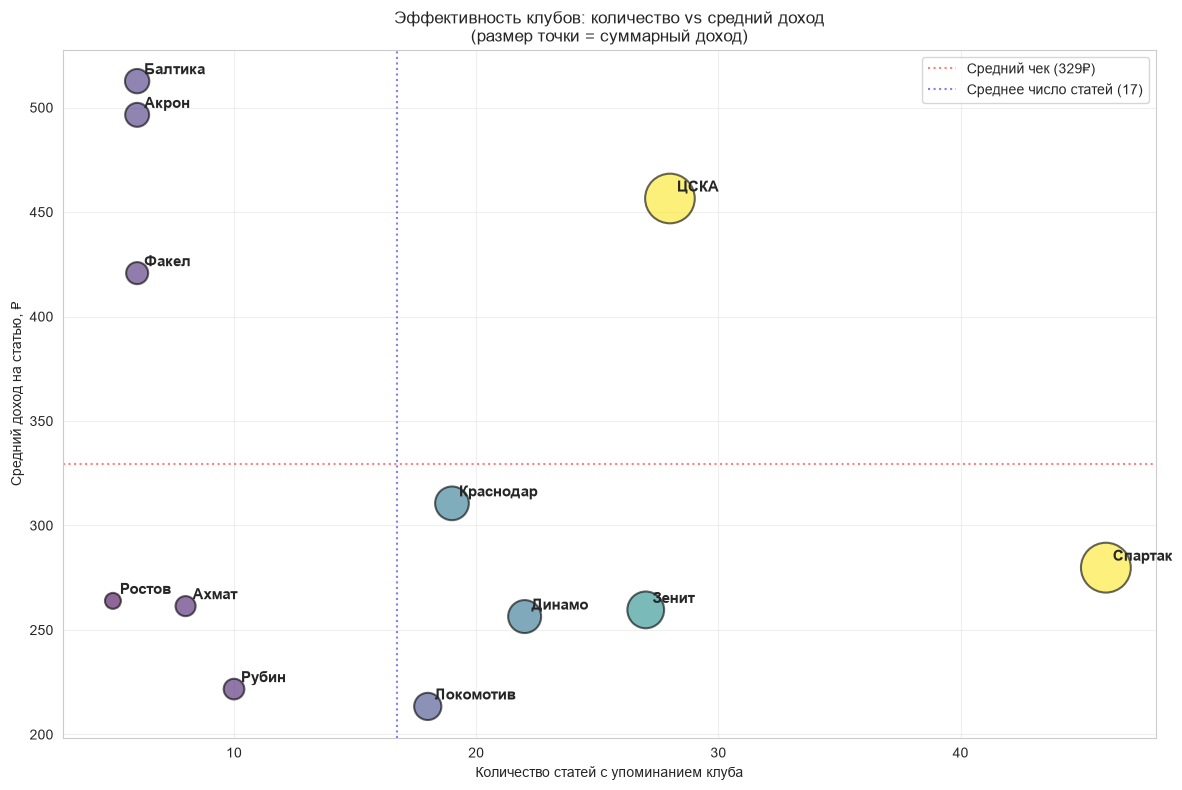

In [23]:
fig, ax = plt.subplots(figsize=(12, 8))

# пузырьковая диаграмма
scatter = ax.scatter(
    club_stats['n'],
    club_stats['avg_income'],
    s=club_stats['total_income'] / 10,  # размер = суммарный доход
    alpha=0.6,
    c=club_stats['total_income'],
    cmap='viridis',
    edgecolors='black',
    linewidth=1.5
)

# подписи клубов
for club, row in club_stats.iterrows():
    ax.annotate(club, (row['n'], row['avg_income']),
                xytext=(5, 5), textcoords='offset points', fontsize=11, fontweight='bold')

# средние линии
ax.axhline(club_stats['avg_income'].mean(), color='red', linestyle=':', alpha=0.5,
           label=f'Средний чек ({club_stats["avg_income"].mean():.0f}₽)')
ax.axvline(club_stats['n'].mean(), color='blue', linestyle=':', alpha=0.5,
           label=f'Среднее число статей ({club_stats["n"].mean():.0f})')

ax.set_xlabel('Количество статей с упоминанием клуба')
ax.set_ylabel('Средний доход на статью, ₽')
ax.set_title('Эффективность клубов: количество vs средний доход\n(размер точки = суммарный доход)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'images' / 'clubs_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# для статей с доходом — сколько дней прошло с публикации
today = pd.Timestamp('2026-09-17')
df_work['days_since_pub'] = (today - df_work['Дата публикации']).dt.days

# корреляция: возраст vs доход
corr = df_work[['days_since_pub', 'Суммарный доход']].corr()
print("Корреляция возраст-доход:", corr.round(3))

# группируем по возрасту
df_work['age_bucket'] = pd.cut(df_work['days_since_pub'], 
                                bins=[0, 30, 90, 180, 365, 1000],
                                labels=['0-30 дн', '30-90 дн', '90-180 дн', '180-365 дн', '365+ дн'])

age_stats = df_work.groupby('age_bucket', observed=True).agg(
    n=('Публикация', 'count'),
    avg_income=('Суммарный доход', 'mean'),
    total_income=('Суммарный доход', 'sum'),
).round(2)
print("\n", age_stats)

Корреляция возраст-доход:                  days_since_pub  Суммарный доход
days_since_pub            1.000           -0.422
Суммарный доход          -0.422            1.000

              n  avg_income  total_income
age_bucket                              
0-30 дн     28      353.19       9889.26
30-90 дн    31      463.80      14377.90
90-180 дн   29      385.79      11187.89
180-365 дн  78      163.42      12747.08
365+ дн     32       78.13       2500.29


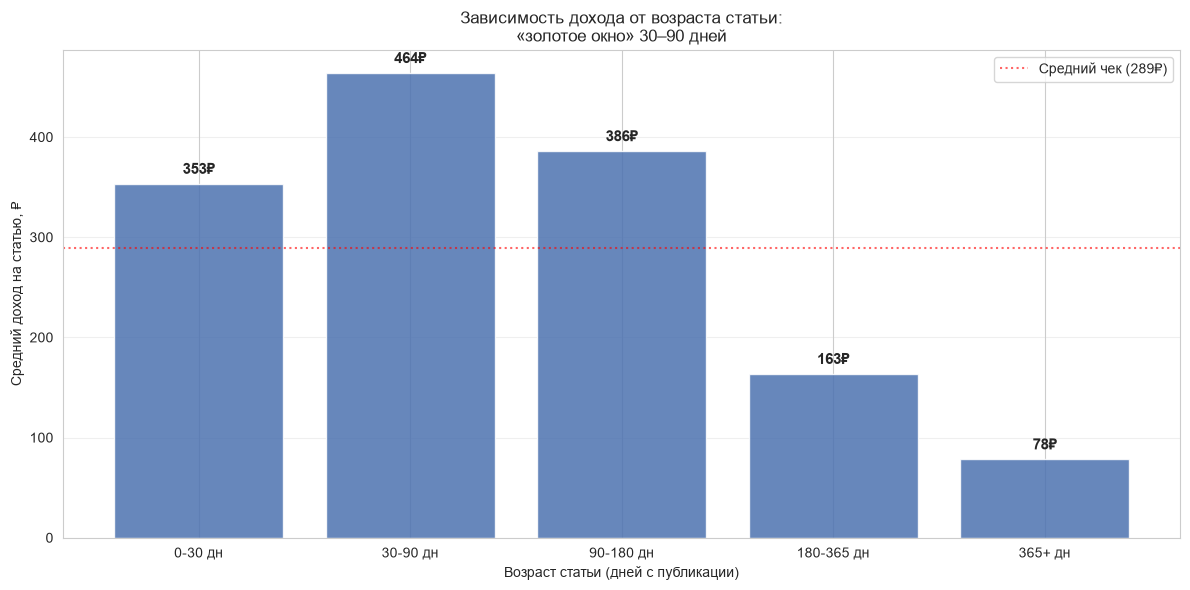

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

age_order = ['0-30 дн', '30-90 дн', '90-180 дн', '180-365 дн', '365+ дн']
age_plot = age_stats.loc[age_order]

bars = ax.bar(age_plot.index, age_plot['avg_income'], color='#4C72B0', alpha=0.85)
ax.axhline(age_stats['avg_income'].mean(), color='red', linestyle=':', 
           alpha=0.6, label=f'Средний чек ({age_stats["avg_income"].mean():.0f}₽)')

for bar, val in zip(bars, age_plot['avg_income']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            f'{val:.0f}₽', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Возраст статьи (дней с публикации)')
ax.set_ylabel('Средний доход на статью, ₽')
ax.set_title('Зависимость дохода от возраста статьи:\n«золотое окно» 30–90 дней')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'images' / 'article_age.png', dpi=150, bbox_inches='tight')
plt.show()


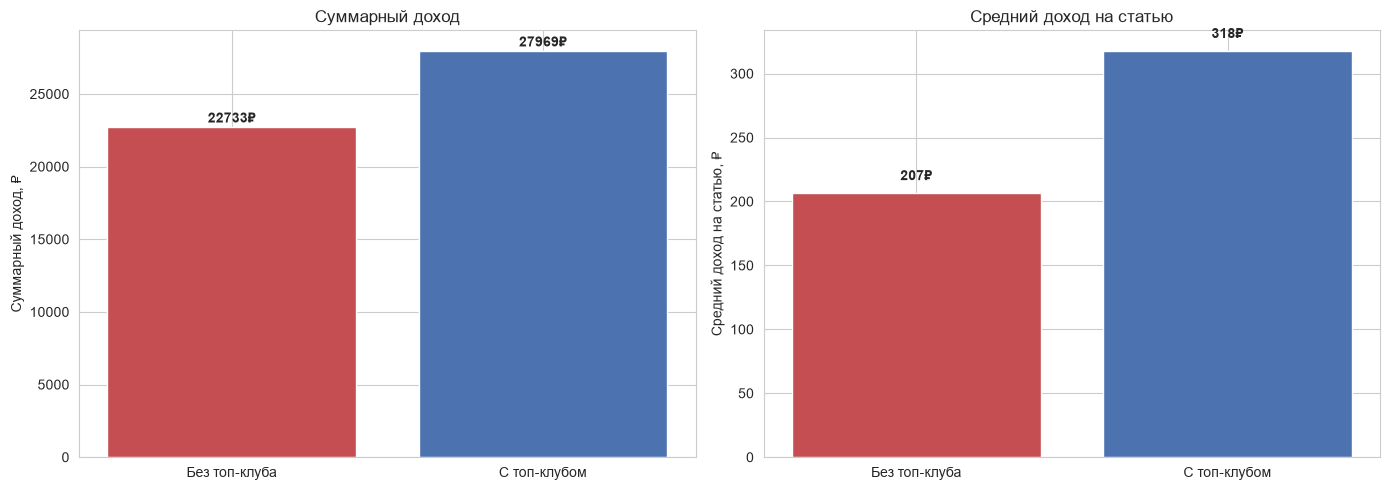

In [26]:
# визуализация: с топ-клубом vs без
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_stats = df_work.groupby('has_top_club').agg(
    n=('Публикация', 'count'),
    total=('Суммарный доход', 'sum'),
    avg=('Суммарный доход', 'mean')
)
top_stats.index = ['Без топ-клуба', 'С топ-клубом']

axes[0].bar(top_stats.index, top_stats['total'], color=['#C44E52', '#4C72B0'])
axes[0].set_ylabel('Суммарный доход, ₽')
axes[0].set_title('Суммарный доход')
for i, v in enumerate(top_stats['total']):
    axes[0].text(i, v + 300, f'{v:.0f}₽', ha='center', fontweight='bold')

axes[1].bar(top_stats.index, top_stats['avg'], color=['#C44E52', '#4C72B0'])
axes[1].set_ylabel('Средний доход на статью, ₽')
axes[1].set_title('Средний доход на статью')
for i, v in enumerate(top_stats['avg']):
    axes[1].text(i, v + 10, f'{v:.0f}₽', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'images' / 'top_club_effect.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
import pandas as pd
df_check = pd.read_csv(r'D:\Projects\dzen-analysis\data\processed\dzen_articles.csv')
print(df_check.columns.tolist())

['Дата публикации', 'Тип публикации', 'Публикация', 'Ссылка на публикацию', 'Дочитывания и просмотры', 'Показы', 'Открытия', 'Время просмотра в минутах', 'Комментарии', 'Подписки', 'Лайки', 'Стеллы', 'Суммарный доход', 'За время просмотра', 'Прочее', 'CTR', 'CR', 'ER', 'RPM', 'year_month', 'weekday', 'hour', 'month', 'CTR_clean', 'CR_clean', 'ER_clean']


In [28]:
from pathlib import Path

# пересохраняем рабочий датасет со ВСЕМИ фичами
PROCESSED = Path.cwd().parent / 'data' / 'processed'

# убедитесь, что df содержит все фичи — он должен, если вы дошли до моделирования
print("Колонки перед сохранением:")
print([c for c in df.columns if c not in ['Публикация', 'Ссылка на публикацию', 'Дата публикации']])

# сохраняем
df.to_csv(PROCESSED / 'dzen_articles.csv', index=False)
print("\nСохранено:", df.shape)

Колонки перед сохранением:
['Тип публикации', 'Дочитывания и просмотры', 'Показы', 'Открытия', 'Время просмотра в минутах', 'Комментарии', 'Подписки', 'Лайки', 'Стеллы', 'Суммарный доход', 'За время просмотра', 'Прочее', 'CTR', 'CR', 'ER', 'RPM', 'year_month', 'weekday', 'hour', 'month', 'CTR_clean', 'CR_clean', 'ER_clean']

Сохранено: (614, 26)


In [29]:
import pandas as pd
df_check = pd.read_csv(r'D:\Projects\dzen-analysis\data\processed\dzen_articles.csv')
print(df_check.columns.tolist())

['Дата публикации', 'Тип публикации', 'Публикация', 'Ссылка на публикацию', 'Дочитывания и просмотры', 'Показы', 'Открытия', 'Время просмотра в минутах', 'Комментарии', 'Подписки', 'Лайки', 'Стеллы', 'Суммарный доход', 'За время просмотра', 'Прочее', 'CTR', 'CR', 'ER', 'RPM', 'year_month', 'weekday', 'hour', 'month', 'CTR_clean', 'CR_clean', 'ER_clean']
